In [ ]:
# subway.csv
# 역별 타/내리 평균
# 3그룹으로(붐빔, 평범, 파리)

# 역명 입력받아서 -> 그 역은 어떤그룹에 속하나

# 탄 사람수, 내린 사람수 입력받아서 -> 그 정도면 어떤그룹에 속할까

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./Users/teacher02/Jan27_1_MachineLearning/subway.csv", 
                names=["년","월","일","노선","역","타","내리"])
df = df.groupby("역")[["타", "내리"]].mean()

                      타            내리  그룹
역                                        
4.19민주묘지    2994.794623   2860.110530   1
가능          6761.949630   6417.983575   1
가락시장        7917.660964   8260.135368   1
가산디지털단지    26457.021489  27727.780044   0
가양         19658.998084  19004.231864   0
...                 ...           ...  ..
회룡         12398.163154  12050.954010   1
회현         29231.298780  31101.428354   0
회현(남대문시장)  25301.806473  26577.192192   0
효창공원앞       4900.677760   4743.686996   1
흑석(중앙대입구)   9042.743225   9269.846701   1

[598 rows x 3 columns]


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from current font.

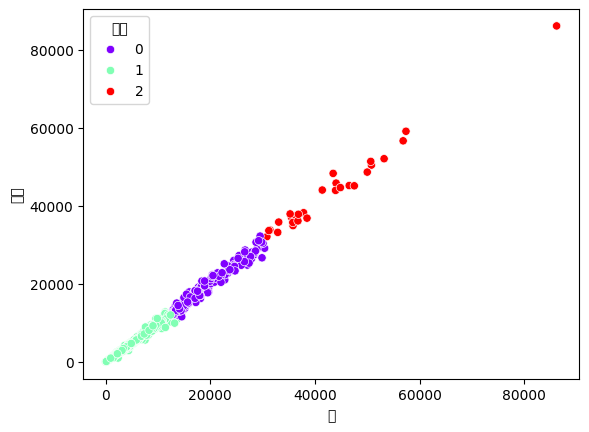

In [ ]:
from sklearn.cluster import KMeans

data = df[["타", "내리"]].to_numpy()

km = KMeans(3)
df["그룹"] = km.fit_predict(data)
sns.scatterplot(df, x="타", y="내리", palette="rainbow", hue="그룹")
plt.show()

In [18]:
df["그룹"] = df["그룹"].replace([0, 1, 2], ["평범", "파리", "붐빔"])

In [23]:
name = input("역명 : ")
print(df.loc[name]["그룹"])
print("-----")
print(df[df["그룹"] == df.loc[name]["그룹"]].index)

붐빔
-----
Index(['강남', '강변', '강변(동서울터미널)', '광화문', '광화문(세종문화회관)', '구로디지털단지', '남부터미널',
       '명동', '부천', '부평', '사당', '삼성', '삼성(무역센터)', '서울대입구', '서울대입구(관악구청)',
       '수유(강북구청)', '신림', '압구정', '양재', '양재(서초구청)', '역삼', '영등포', '용산', '을지로입구',
       '잠실', '잠실(송파구청)', '종각', '혜화'],
      dtype='object', name='역')


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

feature = df[["타", "내리"]].to_numpy()
label = df["그룹"].to_numpy()

knc = KNeighborsClassifier(10)
knc.fit(feature, label)

ta = float(input("타 : "))
naeri = float(input("내리 : "))
predictData = np.array([[ta, naeri]])

result = knc.predict(predictData)[0]
print(result)

평범
